# Fichero `adult.csv` — Preparación de datos y modelo supervisado

Este notebook reúne **todo lo trabajado** hasta ahora:
1. Carga del dataset `adult.csv`
2. Creación del **dataset reducido** (solo columnas objetivo)
3. Limpieza de valores ausentes (`?` → `NaN`) y eliminación de filas incompletas
4. Definición de **X** e **y** (objetivo: `income`)
5. Identificación de variables **numéricas** y **categóricas**
6. Preprocesado con **ColumnTransformer** (StandardScaler + OneHotEncoder)
7. División **train/test**
8. Entrenamiento de un **modelo** (Regresión Logística)
9. Evaluación básica (classification report + matriz de confusión)



## 1. Carga del dataset

Nos aseguramos de que `adult.csv` está en la misma carpeta que este notebook.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

df = pd.read_csv("adult.csv")

df.head(5)

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


## 2. Creación del dataset reducido (solo columnas objetivo)
**Variables que se conservarán (las únicas permitidas en la práctica):**



In [ ]:
columnas_objetivo = [
    "age",
    "workclass",
    "education",
    "occupation",
    "race",
    "sex",
    "capital.gain",
    "capital.loss",
    "hours.per.week",
    "native.country",
    "income"
]


df_modelo = df[columnas_objetivo]

df_modelo.head()

,age,workclass,education,occupation,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,HS-grad,?,White,Female,0,4356,40,United-States,<=50K
1,82,Private,HS-grad,Exec-managerial,White,Female,0,4356,18,United-States,<=50K
2,66,?,Some-college,?,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,7th-8th,Machine-op-inspct,White,Female,0,3900,40,United-States,<=50K
4,41,Private,Some-college,Prof-specialty,White,Female,0,3900,40,United-States,<=50K


## 3. Limpieza del dataset reducido

En adult.csv, los valores ausentes a veces aparecen como `?` en algunas columnas, como podemos ver en la celda anterior
- Sustituimos `?` por `NaN`
- Comprobamos nulos por columna


In [3]:
df_modelo["workclass"] = df_modelo["workclass"].str.replace("?", "NaN")
nulos = df.isnull().sum()
print(nulos)

age               0
workclass         0
fnlwgt            0
education         0
education.num     0
marital.status    0
occupation        0
relationship      0
race              0
sex               0
capital.gain      0
capital.loss      0
hours.per.week    0
native.country    0
income            0
dtype: int64


/tmp/ipykernel_38128/2453182150.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_modelo["workclass"] = df_modelo["workclass"].str.replace("?", "NaN")


In [4]:
df_modelo.head()

,age,workclass,education,occupation,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,NaN,HS-grad,?,White,Female,0,4356,40,United-States,<=50K
1,82,Private,HS-grad,Exec-managerial,White,Female,0,4356,18,United-States,<=50K
2,66,NaN,Some-college,?,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,7th-8th,Machine-op-inspct,White,Female,0,3900,40,United-States,<=50K
4,41,Private,Some-college,Prof-specialty,White,Female,0,3900,40,United-States,<=50K


## 4. Definir el problema supervisado: predicción de salario (`income`)

In [5]:
"""
Predecir si es una persona que va a ganar >50 o <50 entorno a sus temas personales
"""


'\nPredecir si es una persona que va a ganar >50 o <50 entorno a sus temas personales\n'

## 5. Identificación de variables numéricas y categóricas

De lo anterior vemos que hay:
- variables numéricas: 
- variables categóricas:

### Preprocesado de los datos

En esta fase se preparan las variables para su uso en el modelo de Machine Learning.
Dado que el conjunto de datos contiene variables numéricas y categóricas, se aplican
técnicas de preprocesado diferenciadas, incluyendo la imputación de valores nulos,
el escalado de variables numéricas y la codificación de variables categóricas mediante
One-Hot Encoding.


## 6. Preprocesado con sklearn

In [6]:
from sklearn.model_selection import train_test_split

X = df_modelo[['age', "hours.per.week", "capital.gain", "capital.loss"]]

y = df_modelo['income'].to_frame()

In [7]:
X

,age,hours.per.week,capital.gain,capital.loss
0,90,40,0,4356
1,82,18,0,4356
2,66,40,0,4356
3,54,40,0,3900
4,41,40,0,3900
...,...,...,...,...
32556,22,40,0,0
32557,27,38,0,0
32558,40,40,0,0
32559,58,40,0,0


In [8]:
y

,income
0,<=50K
1,<=50K
2,<=50K
3,<=50K
4,<=50K
...,...
32556,<=50K
32557,<=50K
32558,>50K
32559,<=50K


In [9]:
print(X.shape)
print(y.shape)

(32561, 4)
(32561, 1)


Ahora terminamos de preparar todo

## 7. División en entrenamiento y prueba

### Entrenamiento del modelo

Una vez definidos el conjunto de entrenamiento y el preprocesado de los datos,
se procede al entrenamiento de un modelo de clasificación basado en regresión logística,
utilizado como modelo base para este problema.


In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.33, random_state = 0)

In [11]:
from sklearn.linear_model import LogisticRegression as lr

clf = lr(max_iter=1000)
clf.fit(X_train, y_train)

/home/ciabd01/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


LogisticRegression(max_iter=1000)

In [12]:
y_pred = clf.predict(X_test)

## 8. Regresión


### Evaluación del modelo

El rendimiento del modelo se evalúa utilizando distintas métricas de clasificación,
así como la matriz de confusión, con el objetivo de analizar su capacidad predictiva
y detectar posibles limitaciones.


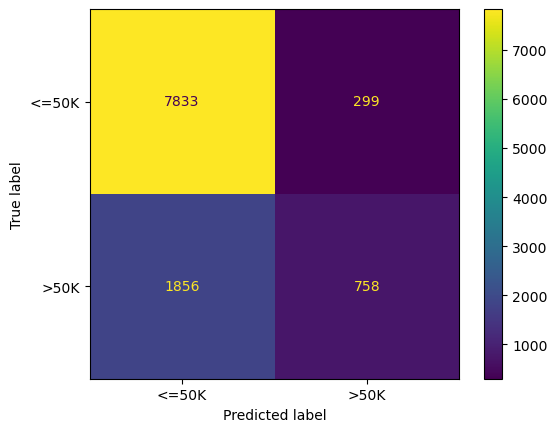

In [13]:
# Matriz de confusión

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=clf.classes_)

disp.plot()
plt.show()

## 9. Evaluación del modelo


In [14]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7994602642843849
              precision    recall  f1-score   support

       <=50K       0.81      0.96      0.88      8132
        >50K       0.72      0.29      0.41      2614

    accuracy                           0.80     10746
   macro avg       0.76      0.63      0.65     10746
weighted avg       0.79      0.80      0.77     10746

